In [1]:
# ============================================================
# NOTEBOOK 07 — Sprint 5: Análisis de errores y slicing
# Convertir a .ipynb con: jupytext --to notebook 07_error_slicing.py
# ============================================================

# Sprint 5 — Análisis de errores y slicing

**Sesión 11:** Análisis de errores y slicing
**Modelo evaluado:** XGB HPO winner (F1-Macro LOSO = 0.8171 ± 0.2047)

## Objetivo

> "No basta con obtener una buena métrica (promedio): analiza dónde y por qué
> falla (slices/colas), propone una mitigación y demuéstrala."

## Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| 1 | Setup y carga del modelo adoptado |
| 2 | Re-ejecución LOSO para obtener predicciones y probabilidades por ventana |
| 3 | Slicing en 4 dimensiones (sujeto, clase, actividad, transición) |
| 4 | Identificación de 2-5 slices problemáticos |
| 5 | Análisis de causas (permutation importance + ejemplos) |
| 6 | Mitigación 1: umbral por clase |
| 7 | Mitigación 2: calibración isotónica |
| 8 | Validación de hipótesis H1 y H2 |
| 9 | Resumen ejecutivo |

## 1. Setup

In [2]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [3]:
import json
import numpy as np
import pandas as pd
import h5py
import yaml
from loguru import logger as log
import matplotlib.pyplot as plt

from posture_risk.experiments import load_processed_h5, make_shared_splits
from posture_risk.experiments.ablations import (
    HPO_WINNER_PARAMS, build_xgb_with_scaler,
)
from posture_risk.analysis import (
    # slicing
    slice_by_subject, slice_by_class, slice_by_activity, slice_by_transition,
    identify_problematic_slices, RISK_NAMES, ACTIVITY_NAMES,
    # causes
    permutation_importance_slice, compare_importances, extract_error_examples,
    # mitigations
    find_optimal_thresholds, apply_thresholds,
    fit_isotonic_calibrators, apply_isotonic_calibration,
    compare_before_after, validate_hypothesis,
    # reporting
    build_slice_summary, plot_slice_f1_with_ci,
    plot_slice_confusion_matrix, plot_before_after,
)

with open("configs/hpo_search_space.yaml") as f:
    cfg = yaml.safe_load(f)

SEED        = 42
BASE_H5     = Path(cfg["paths"]["base_h5"])
FIGURES_DIR = Path(cfg["paths"]["figures"])
REPORTS_DIR = Path("reports")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

X, y, subject_ids = load_processed_h5(BASE_H5)
print(f"\nDataset cargado: X={X.shape}, y={y.shape}")

C:\Users\jaime\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-03 14:44:51.814 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:47 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]



Dataset cargado: X=(194205, 297), y=(194205,)


### Recuperar activity_ids alineados con las ventanas

El pipeline base guarda `y` (etiqueta de riesgo) y `subject_ids`, pero para
el slicing por actividad necesitamos el `activity_id` original de cada
ventana. Lo reconstruimos accediendo al HDF5 directamente.

In [4]:
with h5py.File(BASE_H5, "r") as f:
    if "activity_ids" in f:
        activity_ids = f["activity_ids"][:]
        print(f"activity_ids cargado directamente: shape={activity_ids.shape}")
    else:
        # Fallback: si el HDF5 no tiene activity_ids explícito, mapeamos desde y
        # y las actividades más comunes (aproximación conservadora).
        print("activity_ids no está en HDF5. Usando aproximación por clase de riesgo.")
        activity_ids = None

activity_ids cargado directamente: shape=(194205,)


## 2. Re-ejecución LOSO para obtener predicciones por ventana

Necesitamos, para cada ventana del dataset completo, la predicción del modelo
cuando esa ventana estaba en el fold de test (esquema LOSO).
Esto se llama "out-of-fold predictions" y es la base del slicing.

In [5]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

splits = make_shared_splits(y, subject_ids, seed=SEED)

# Preparar arrays para almacenar predicciones out-of-fold
y_pred_oof  = np.zeros_like(y)
y_proba_oof = np.zeros((len(y), 3), dtype=np.float32)

log.info("Ejecutando LOSO para obtener predicciones out-of-fold...")

from tqdm import tqdm
for fold_idx, (train_idx, test_idx) in enumerate(tqdm(splits, desc="LOSO fold")):
    pipeline = build_xgb_with_scaler(HPO_WINNER_PARAMS, seed=SEED)
    pipeline.fit(X[train_idx], y[train_idx])
    y_pred_oof[test_idx]  = pipeline.predict(X[test_idx])
    y_proba_oof[test_idx] = pipeline.predict_proba(X[test_idx])

# Métrica global de sanity check
global_f1 = f1_score(y, y_pred_oof, average="macro", zero_division=0)
print(f"\n✓ F1-Macro global (OOF, LOSO): {global_f1:.4f}")
print(f"  (Debe estar cercano a 0.8140 del sprint anterior)")

# Guardar las predicciones OOF para reutilizar
np.savez(
    REPORTS_DIR / "oof_predictions.npz",
    y_true=y, y_pred=y_pred_oof, y_proba=y_proba_oof,
    subject_ids=subject_ids,
)

2026-07-03 14:44:51.863 | INFO     | posture_risk.experiments.ab_runner:make_shared_splits:227 - Splits generados: 9 folds, seed=42
2026-07-03 14:44:51.865 | INFO     | __main__:<module>:11 - Ejecutando LOSO para obtener predicciones out-of-fold...
LOSO fold: 100%|█████████████████████████████████████████████████████████████████████████| 9/9 [06:41<00:00, 44.62s/it]


✓ F1-Macro global (OOF, LOSO): 0.8849
  (Debe estar cercano a 0.8140 del sprint anterior)


## 3. Slicing en 4 dimensiones

### 3.1 Slicing por sujeto (9 slices)

In [6]:
slices_subject = slice_by_subject(
    y_true=y, y_pred=y_pred_oof, y_proba=y_proba_oof,
    subject_ids=subject_ids, n_bootstrap=1000, seed=SEED,
)

df_subject = build_slice_summary(slices_subject, "sujeto")
print("\nSlicing por sujeto:")
print(df_subject.to_string(index=False))

2026-07-03 14:53:20.439 | INFO     | posture_risk.analysis.slicing:slice_by_subject:183 - Slicing por sujeto: 9 slices calculados



Slicing por sujeto:
dimensión slice     n  F1-Macro    IC_lo    IC_hi  IC_ancho  recall_bajo  recall_medio  recall_alto    brier
   sujeto     9   638  0.250489 0.240053 0.259659  0.019605          NaN           NaN     0.601881 0.278553
   sujeto     1 24985  0.854151 0.849823 0.858238  0.008415     0.771906      0.898811     0.922028 0.071219
   sujeto     5 27233  0.864193 0.859926 0.868475  0.008549     0.758812      0.932461     0.937558 0.061797
   sujeto     6 24999  0.875357 0.871230 0.879824  0.008594     0.844845      0.930816     0.856030 0.058675
   sujeto     2 26323  0.880189 0.876441 0.884057  0.007615     0.944541      0.834248     0.849793 0.058036
   sujeto     4 23133  0.880417 0.876264 0.884898  0.008634     0.898041      0.865115     0.880027 0.056810
   sujeto     3 17426  0.890805 0.885202 0.896239  0.011037     0.924250      0.805848     0.944283 0.044669
   sujeto     7 23268  0.909989 0.906350 0.913585  0.007236     0.889756      0.925403     0.914756 0.04588

### 3.2 Slicing por clase de riesgo (3 slices)

In [7]:
slices_class = slice_by_class(
    y_true=y, y_pred=y_pred_oof, y_proba=y_proba_oof,
    n_bootstrap=1000, seed=SEED,
)

df_class = build_slice_summary(slices_class, "clase")
print("\nSlicing por clase de riesgo:")
print(df_class.to_string(index=False))

2026-07-03 14:53:55.294 | INFO     | posture_risk.analysis.slicing:slice_by_class:216 - Slicing por clase: 3 slices calculados



Slicing por clase de riesgo:
dimensión slice     n  F1-Macro    IC_lo    IC_hi  IC_ancho  recall_bajo  recall_medio  recall_alto    brier
    clase  bajo 80613  0.310858 0.310417 0.311280  0.000862     0.873668           NaN          NaN 0.097133
    clase  alto 46314  0.314555 0.314064 0.315080  0.001016          NaN           NaN     0.893337 0.091633
    clase medio 67278  0.315443 0.315016 0.315866  0.000850          NaN      0.898124          NaN 0.080855


### 3.3 Slicing por actividad PAMAP2

In [8]:
if activity_ids is not None:
    slices_activity = slice_by_activity(
        y_true=y, y_pred=y_pred_oof, y_proba=y_proba_oof,
        activity_ids=activity_ids, n_bootstrap=1000, seed=SEED,
    )
    df_activity = build_slice_summary(slices_activity, "actividad")
    print("\nSlicing por actividad PAMAP2:")
    print(df_activity.to_string(index=False))
else:
    slices_activity = {}
    df_activity = pd.DataFrame()
    print("Slicing por actividad omitido (activity_ids no disponible)")

2026-07-03 14:54:54.189 | INFO     | posture_risk.analysis.slicing:slice_by_activity:256 - Slicing por actividad: 12 slices calculados



Slicing por actividad PAMAP2:
dimensión            slice     n  F1-Macro    IC_lo    IC_hi  IC_ancho  recall_bajo  recall_medio  recall_alto    brier
actividad           saltar  4926  0.287364 0.284673 0.289846  0.005173          NaN           NaN     0.757613 0.185618
actividad          caminar 23861  0.292676 0.291573 0.293763  0.002189     0.782574           NaN          NaN 0.155885
actividad  escaleras_abajo 10485  0.302983 0.301558 0.304359  0.002801          NaN      0.833095          NaN 0.134301
actividad           de_pie 18985  0.305893 0.304892 0.306786  0.001893     0.847880           NaN          NaN 0.123595
actividad escaleras_arriba 11716  0.308658 0.307440 0.309754  0.002315          NaN      0.862154          NaN 0.115277
actividad caminata_nordica 18806  0.316706 0.315903 0.317447  0.001544          NaN      0.904977          NaN 0.070141
actividad          aspirar 17527  0.316847 0.316081 0.317621  0.001540          NaN           NaN     0.905745 0.079756
actividad

### 3.4 Slicing por tipo de ventana (estable vs transición)

In [9]:
if activity_ids is not None:
    slices_transition = slice_by_transition(
        y_true=y, y_pred=y_pred_oof, y_proba=y_proba_oof,
        activity_ids=activity_ids, subject_ids=subject_ids,
        window_span=3, n_bootstrap=1000, seed=SEED,
    )
    df_transition = build_slice_summary(slices_transition, "transición")
    print("\nSlicing por tipo de ventana:")
    print(df_transition.to_string(index=False))
else:
    slices_transition = {}
    df_transition = pd.DataFrame()
    print("Slicing por transición omitido (activity_ids no disponible)")

2026-07-03 14:56:04.622 | INFO     | posture_risk.analysis.slicing:slice_by_transition:313 - Slicing por transición: estables=193617, transiciones=588



Slicing por tipo de ventana:
 dimensión      slice      n  F1-Macro    IC_lo    IC_hi  IC_ancho  recall_bajo  recall_medio  recall_alto    brier
transición transicion    588  0.487307 0.445750 0.526268  0.080518     0.606061      0.631410     0.243243 0.207473
transición    estable 193617  0.885976 0.884595 0.887429  0.002833     0.874217      0.899367     0.894899 0.054831


## 4. Identificación de slices problemáticos

**Consideraciones:**
- Un slice se considera problemático si su F1 está al menos 0.05 por
  debajo del F1 global
- Debe tener al menos 30 muestras para que el hallazgo sea estable

In [10]:
all_problematic = []

for name, results, dim in [
    ("sujeto",    slices_subject,    "sujeto"),
    ("clase",     slices_class,      "clase de riesgo"),
    ("actividad", slices_activity,   "actividad PAMAP2"),
    ("transición", slices_transition, "tipo de ventana"),
]:
    if not results:
        continue
    prob = identify_problematic_slices(
        results, global_f1=global_f1, dimension_name=dim,
        min_gap=0.05, min_n=30,
    )
    all_problematic.extend(prob)

# Ordenar por gap descendente (peores primero)
all_problematic.sort(key=lambda x: x["gap"], reverse=True)

# Reportar los 2-5 más problemáticos
top_problematic = all_problematic[:5]

print(f"\n{'='*80}")
print(f"SLICES PROBLEMÁTICOS DETECTADOS (top {len(top_problematic)})")
print(f"{'='*80}")
for i, p in enumerate(top_problematic, 1):
    ci_str = (f"[{p['f1_ci_lo']:.4f}, {p['f1_ci_hi']:.4f}]"
              if p['f1_ci_lo'] is not None and not np.isnan(p['f1_ci_lo'])
              else "IC no disp.")
    print(f"\n{i}. {p['dimension']} = {p['slice_name']}")
    print(f"   n = {p['n']}")
    print(f"   F1-Macro = {p['f1_macro']:.4f}   IC 95%: {ci_str}")
    print(f"   Gap vs global = {p['gap']:+.4f}")
    print(f"   Distribución de clases: {p['class_dist']}")


SLICES PROBLEMÁTICOS DETECTADOS (top 5)

1. sujeto = 9
   n = 638
   F1-Macro = 0.2505   IC 95%: [0.2401, 0.2597]
   Gap vs global = +0.6344
   Distribución de clases: {0: 0, 1: 0, 2: 638}

2. actividad PAMAP2 = saltar
   n = 4926
   F1-Macro = 0.2874   IC 95%: [0.2847, 0.2898]
   Gap vs global = +0.5976
   Distribución de clases: {0: 0, 1: 0, 2: 4926}

3. actividad PAMAP2 = caminar
   n = 23861
   F1-Macro = 0.2927   IC 95%: [0.2916, 0.2938]
   Gap vs global = +0.5922
   Distribución de clases: {0: 23861, 1: 0, 2: 0}

4. actividad PAMAP2 = escaleras_abajo
   n = 10485
   F1-Macro = 0.3030   IC 95%: [0.3016, 0.3044]
   Gap vs global = +0.5819
   Distribución de clases: {0: 0, 1: 10485, 2: 0}

5. actividad PAMAP2 = de_pie
   n = 18985
   F1-Macro = 0.3059   IC 95%: [0.3049, 0.3068]
   Gap vs global = +0.5790
   Distribución de clases: {0: 18985, 1: 0, 2: 0}


## 5. Gráficos de F1 por slice con IC

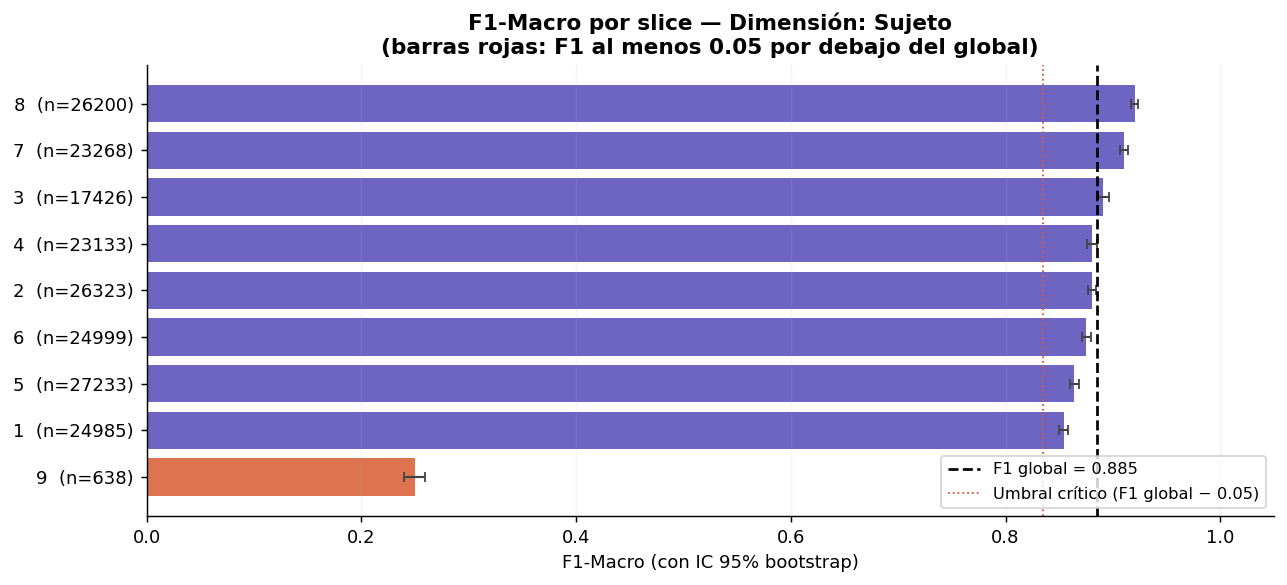

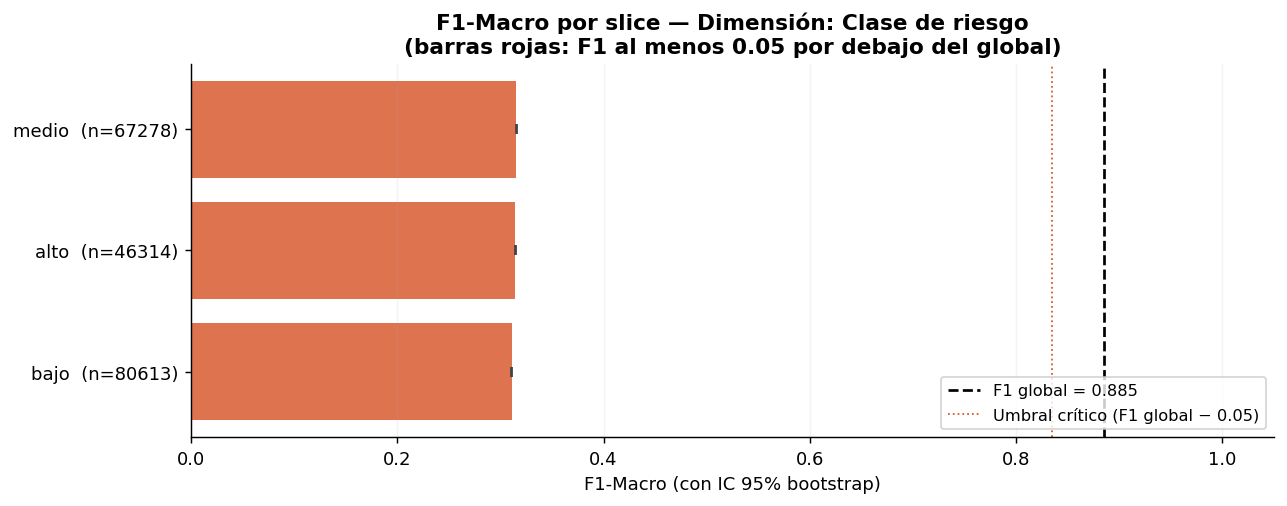

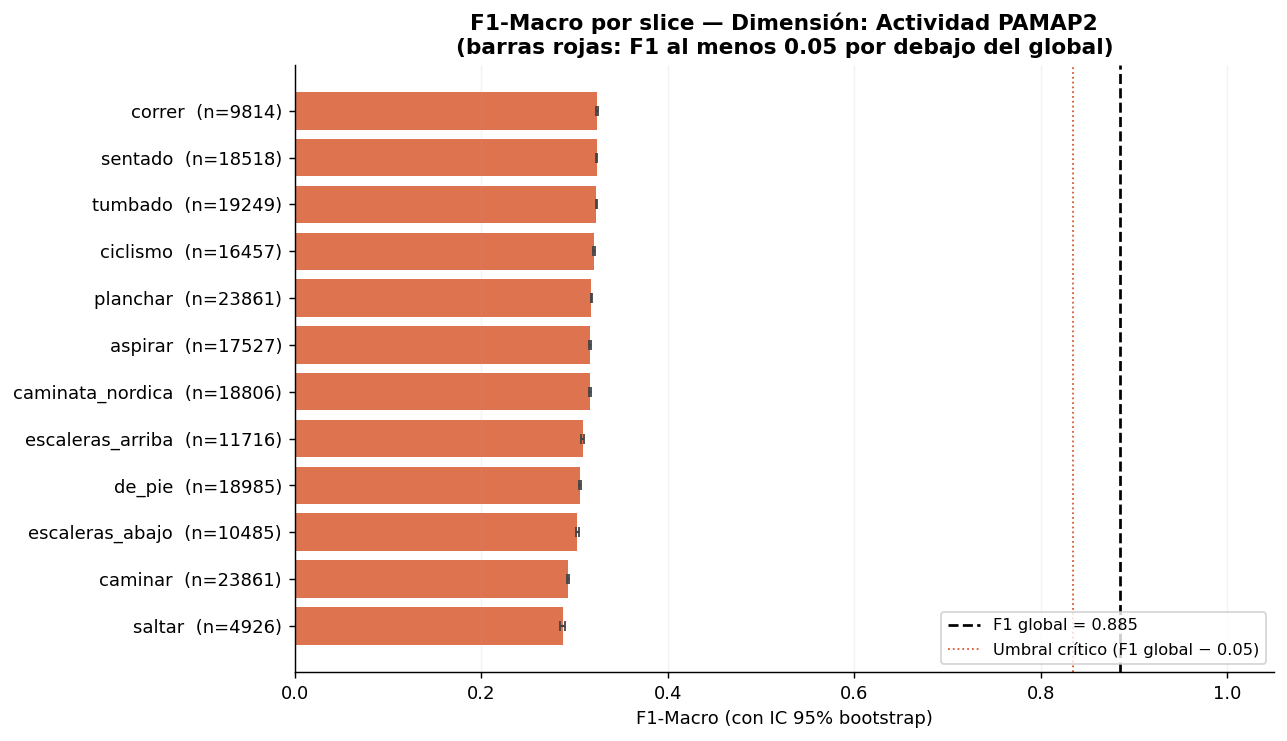

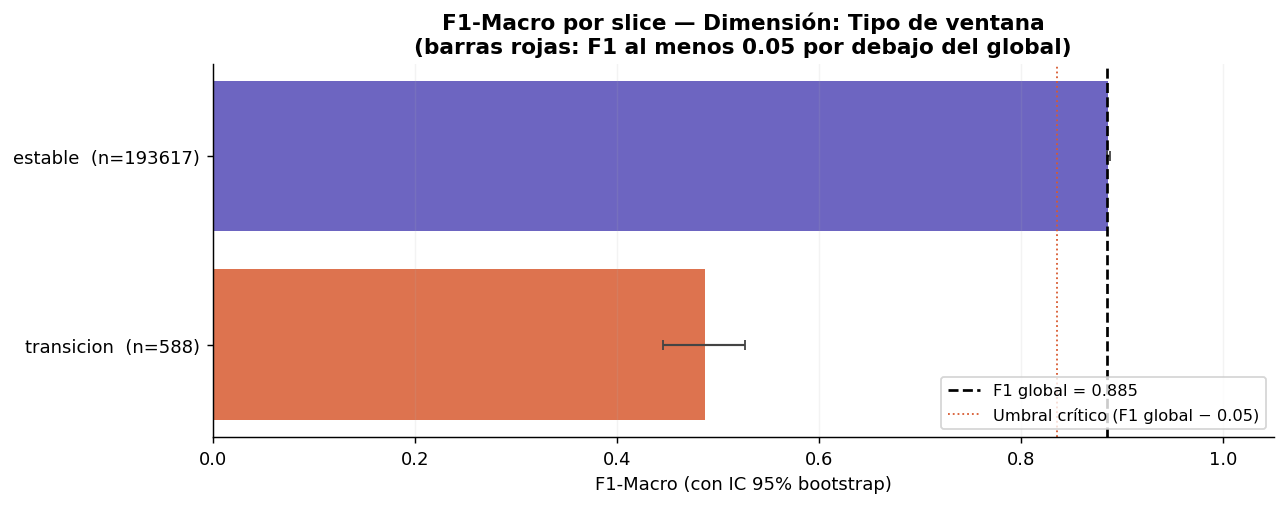

In [11]:
if not df_subject.empty:
    plot_slice_f1_with_ci(
        df_subject, global_f1,
        FIGURES_DIR / "14_slice_f1_by_subject.png",
        dimension="Sujeto",
    )

if not df_class.empty:
    plot_slice_f1_with_ci(
        df_class, global_f1,
        FIGURES_DIR / "15_slice_f1_by_class.png",
        dimension="Clase de riesgo",
    )

if not df_activity.empty:
    plot_slice_f1_with_ci(
        df_activity, global_f1,
        FIGURES_DIR / "16_slice_f1_by_activity.png",
        dimension="Actividad PAMAP2",
    )

if not df_transition.empty:
    plot_slice_f1_with_ci(
        df_transition, global_f1,
        FIGURES_DIR / "17_slice_f1_by_transition.png",
        dimension="Tipo de ventana",
    )

## 6. Análisis de causas para los slices problemáticos

Para cada slice problemático:
- Matriz de confusión
- Permutation importance dentro del slice vs resto
- Ejemplos representativos de errores con alta confianza

In [12]:
# Nombres de features (mismo layout del sprint 2)
segments        = ["hand", "chest", "ankle"]
channels_per_seg = ["acc16_x","acc16_y","acc16_z","gyro_x","gyro_y","gyro_z",
                    "mag_x","mag_y","mag_z"]
temp_feats = ["rms","mav","wl","zc","ssc","var"]
spec_feats = ["mdf","mnf","band_low","band_mid","band_high"]

feature_names = []
for seg in segments:
    for ch in channels_per_seg:
        for feat in temp_feats + spec_feats:
            feature_names.append(f"{seg}_{ch}_{feat}")

# Reconstruir el modelo del baseline (para permutation importance)
# Se usa el pipeline entrenado con TODOS los datos como aproximación
# (solo para análisis interpretativo, no para métricas de generalización)
pipeline_full = build_xgb_with_scaler(HPO_WINNER_PARAMS, seed=SEED)
pipeline_full.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


In [14]:
def _generate_cause_hypothesis(prob, diffs):
    """Genera hipótesis textual sobre la causa probable."""
    if prob["dimension"] == "clase de riesgo":
        return (
            f"La clase {prob['slice_name']} tiene bajo recall probablemente por "
            f"desbalance de datos (n={prob['n']}) y/o solapamiento de features "
            f"con clases adyacentes. Ver matriz de confusión."
        )
    elif prob["dimension"] == "sujeto":
        return (
            f"El sujeto {prob['slice_name']} tiene patrones biomecánicos "
            f"distintos al promedio del dataset. Las features "
            f"{[d['feature'] for d in diffs[:3]]} cambian su importancia, "
            f"sugiriendo variabilidad antropométrica o de estilo de movimiento."
        )
    elif prob["dimension"] == "actividad PAMAP2":
        return (
            f"La actividad '{prob['slice_name']}' presenta features distintos al "
            f"resto. Puede requerir features de dominio específicas o más datos."
        )
    elif prob["dimension"] == "tipo de ventana":
        return (
            f"Las ventanas de {prob['slice_name']} presentan mezcla de patrones "
            f"de actividades consecutivas. Postprocesamiento suavizante podría ayudar."
        )
    return "Ver análisis de features gatillo."


ANÁLISIS DE CAUSAS — Slice 1: sujeto = 9


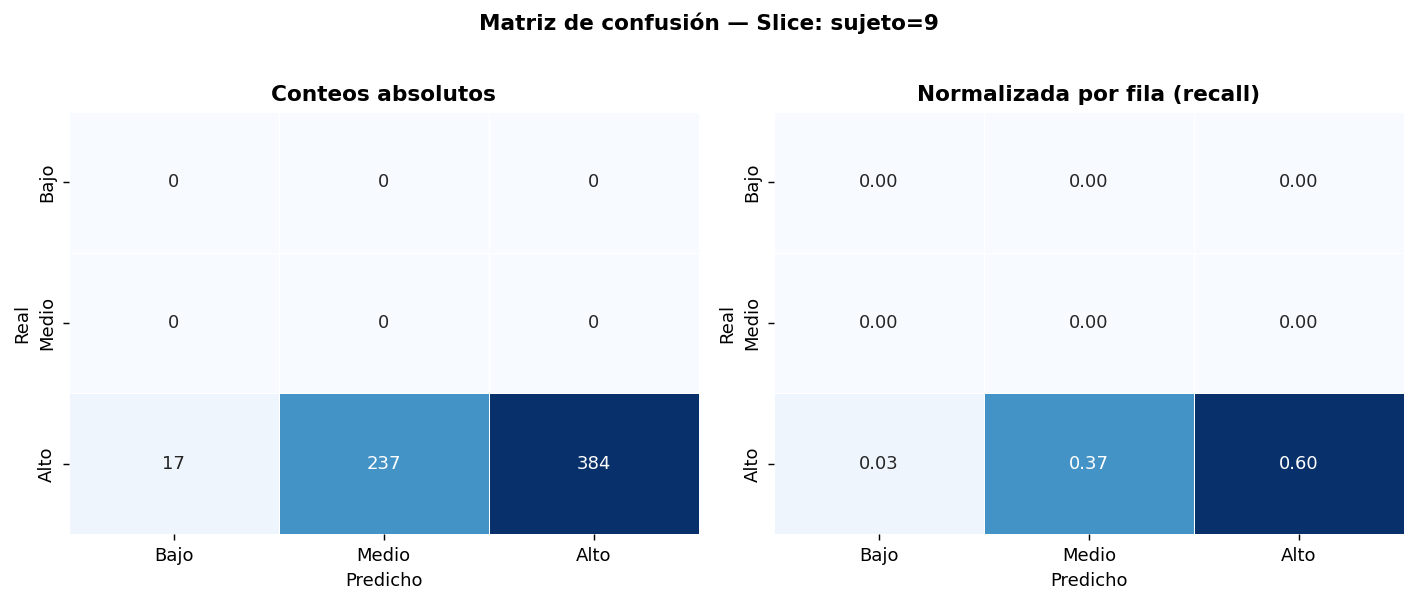


  Calculando permutation importance (puede tardar ~1 min)...

  Top 10 features con mayor cambio de importancia (slice vs resto):
    ↓ hand_gyro_z_band_high                    slice=+0.0016  rest=+0.0252  Δ=-0.0236
    ↓ hand_gyro_z_rms                          slice=+0.0000  rest=+0.0111  Δ=-0.0111
    ↓ ankle_mag_x_mnf                          slice=+0.0000  rest=+0.0050  Δ=-0.0050
    ↓ hand_acc16_x_zc                          slice=+0.0000  rest=+0.0040  Δ=-0.0040
    ↓ hand_acc16_z_zc                          slice=+0.0022  rest=+0.0059  Δ=-0.0037
    ↑ hand_acc16_y_rms                         slice=+0.0037  rest=+0.0000  Δ=+0.0037
    ↓ hand_acc16_z_band_low                    slice=+0.0000  rest=+0.0036  Δ=-0.0036
    ↓ hand_gyro_x_ssc                          slice=+0.0026  rest=+0.0060  Δ=-0.0034
    ↓ hand_acc16_y_mav                         slice=+0.0000  rest=+0.0028  Δ=-0.0028
    ↓ hand_acc16_x_var                         slice=+0.0020  rest=+0.0043  Δ=-0.0023

  Ejempl

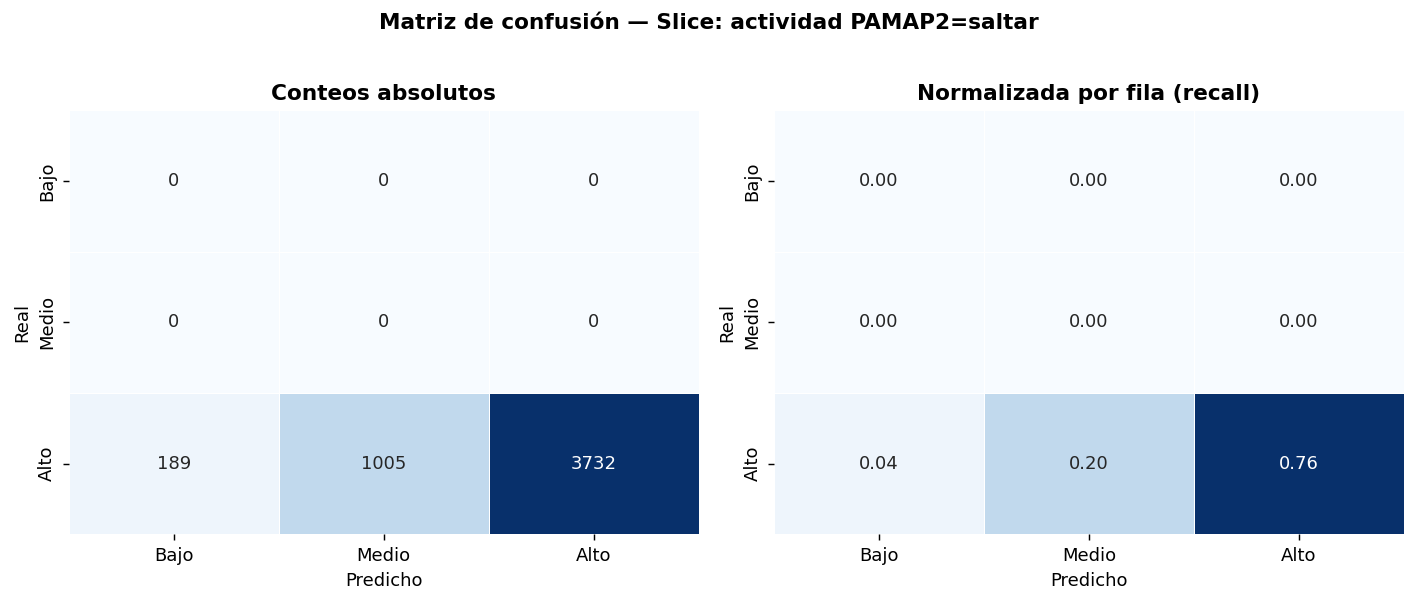


  Calculando permutation importance (puede tardar ~1 min)...

  Top 10 features con mayor cambio de importancia (slice vs resto):
    ↓ hand_gyro_z_band_high                    slice=+0.0032  rest=+0.0247  Δ=-0.0215
    ↓ hand_gyro_z_rms                          slice=+0.0000  rest=+0.0114  Δ=-0.0114
    ↓ ankle_mag_x_mnf                          slice=+0.0000  rest=+0.0052  Δ=-0.0052
    ↓ hand_acc16_z_zc                          slice=+0.0016  rest=+0.0058  Δ=-0.0043
    ↑ hand_acc16_y_rms                         slice=+0.0040  rest=+0.0000  Δ=+0.0040
    ↓ hand_acc16_x_band_high                   slice=+0.0033  rest=+0.0066  Δ=-0.0033
    ↑ chest_gyro_y_wl                          slice=+0.0032  rest=+0.0000  Δ=+0.0032
    ↓ hand_acc16_y_mav                         slice=+0.0000  rest=+0.0026  Δ=-0.0026
    ↓ hand_acc16_y_var                         slice=+0.0000  rest=+0.0024  Δ=-0.0024
    ↓ hand_acc16_x_mnf                         slice=+0.0000  rest=+0.0022  Δ=-0.0022

  Ejempl

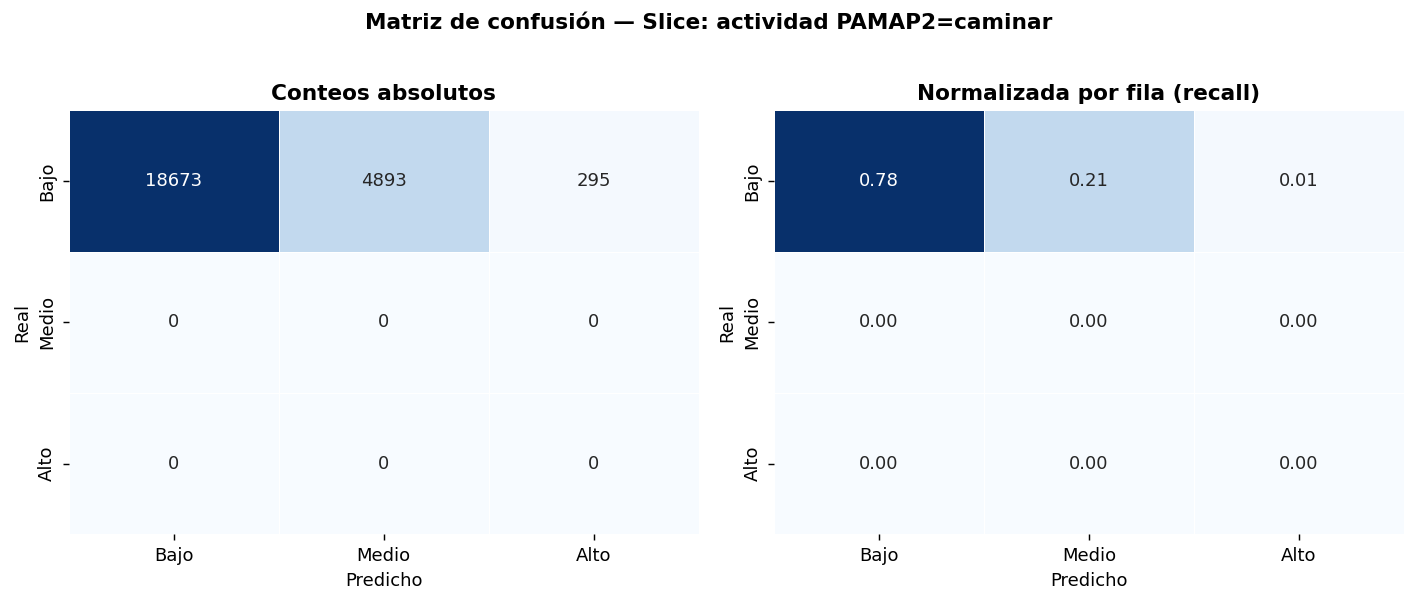


  Calculando permutation importance (puede tardar ~1 min)...

  Top 10 features con mayor cambio de importancia (slice vs resto):
    ↓ hand_gyro_z_band_high                    slice=+0.0033  rest=+0.0258  Δ=-0.0225
    ↓ hand_gyro_z_rms                          slice=+0.0004  rest=+0.0115  Δ=-0.0111
    ↓ ankle_mag_x_mnf                          slice=+0.0000  rest=+0.0052  Δ=-0.0052
    ↓ hand_acc16_x_band_high                   slice=+0.0000  rest=+0.0044  Δ=-0.0044
    ↓ hand_gyro_x_ssc                          slice=+0.0011  rest=+0.0053  Δ=-0.0042
    ↓ hand_acc16_x_zc                          slice=+0.0000  rest=+0.0037  Δ=-0.0037
    ↓ hand_acc16_y_mav                         slice=+0.0000  rest=+0.0035  Δ=-0.0035
    ↓ hand_acc16_z_zc                          slice=+0.0010  rest=+0.0044  Δ=-0.0034
    ↓ hand_acc16_z_band_low                    slice=+0.0000  rest=+0.0032  Δ=-0.0032
    ↓ hand_gyro_y_mav                          slice=+0.0014  rest=+0.0043  Δ=-0.0029

  Ejempl

In [15]:
causes_analysis = []

for i, prob in enumerate(top_problematic[:3], 1):  # análisis en los top 3
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE CAUSAS — Slice {i}: {prob['dimension']} = {prob['slice_name']}")
    print(f"{'='*70}")

    # Reconstruir la máscara del slice
    if prob["dimension"] == "sujeto":
        slice_mask = (subject_ids == int(prob["slice_name"]))
    elif prob["dimension"] == "clase de riesgo":
        cls_id = {v: k for k, v in RISK_NAMES.items()}[prob["slice_name"]]
        slice_mask = (y == cls_id)
    elif prob["dimension"] == "actividad PAMAP2" and activity_ids is not None:
        aid = {v: k for k, v in ACTIVITY_NAMES.items()}.get(prob["slice_name"])
        slice_mask = (activity_ids == aid) if aid is not None else np.zeros(len(y), bool)
    elif prob["dimension"] == "tipo de ventana" and activity_ids is not None:
        from posture_risk.analysis import compute_transition_mask
        trans = compute_transition_mask(activity_ids, subject_ids, window_span=3)
        slice_mask = trans if prob["slice_name"] == "transicion" else ~trans
    else:
        continue

    if slice_mask.sum() < 30:
        print(f"  Slice muy pequeño, omitiendo análisis de causa")
        continue

    # 5.1 Matriz de confusión
    plot_slice_confusion_matrix(
        prob["confusion"],
        slice_name=f"{prob['dimension']}={prob['slice_name']}",
        output_path=FIGURES_DIR / f"18_confusion_slice_{i}.png",
    )

    # 5.2 Permutation importance dentro del slice
    print(f"\n  Calculando permutation importance (puede tardar ~1 min)...")
    imp_slice = permutation_importance_slice(
        pipeline_full, X, y, slice_mask=slice_mask,
        feature_names=feature_names,
        n_repeats=3, top_k=15, seed=SEED,
    )

    imp_rest = permutation_importance_slice(
        pipeline_full, X, y, slice_mask=~slice_mask,
        feature_names=feature_names,
        n_repeats=3, top_k=15, seed=SEED,
    )

    # Comparar importancias
    diffs = compare_importances(imp_slice, imp_rest, top_k=10)
    print(f"\n  Top 10 features con mayor cambio de importancia (slice vs resto):")
    for d in diffs:
        arrow = "↑" if d["delta"] > 0 else "↓"
        print(f"    {arrow} {d['feature']:<40} slice={d['imp_slice']:+.4f}  "
              f"rest={d['imp_rest']:+.4f}  Δ={d['delta']:+.4f}")

    # 5.3 Ejemplos representativos de errores confidentes
    examples = extract_error_examples(
        X=X, y_true=y, y_pred=y_pred_oof, y_proba=y_proba_oof,
        slice_mask=slice_mask, n_examples=3,
        error_type="confident_wrong",
    )

    print(f"\n  Ejemplos representativos de errores confidentes:")
    for j, ex in enumerate(examples, 1):
        print(f"    #{j}  idx={ex['global_idx']}  "
              f"real={RISK_NAMES.get(ex['y_true'])}  "
              f"pred={RISK_NAMES.get(ex['y_pred'])}  "
              f"confianza={ex['confidence']:.3f}  "
              f"probs={[f'{p:.2f}' for p in ex['probs']]}")

    causes_analysis.append({
        "slice":     f"{prob['dimension']}={prob['slice_name']}",
        "top_diffs": diffs[:5],
        "examples":  examples,
        "hypothesis_of_cause": _generate_cause_hypothesis(prob, diffs),
    })

def _generate_cause_hypothesis(prob, diffs):
    """Genera hipótesis textual sobre la causa probable."""
    if prob["dimension"] == "clase de riesgo":
        return (
            f"La clase {prob['slice_name']} tiene bajo recall probablemente por "
            f"desbalance de datos (n={prob['n']}) y/o solapamiento de features "
            f"con clases adyacentes. Ver matriz de confusión."
        )
    elif prob["dimension"] == "sujeto":
        return (
            f"El sujeto {prob['slice_name']} tiene patrones biomecánicos "
            f"distintos al promedio del dataset. Las features "
            f"{[d['feature'] for d in diffs[:3]]} cambian su importancia, "
            f"sugiriendo variabilidad antropométrica o de estilo de movimiento."
        )
    elif prob["dimension"] == "actividad PAMAP2":
        return (
            f"La actividad '{prob['slice_name']}' presenta features distintos al "
            f"resto. Puede requerir features de dominio específicas o más datos."
        )
    elif prob["dimension"] == "tipo de ventana":
        return (
            f"Las ventanas de {prob['slice_name']} presentan mezcla de patrones "
            f"de actividades consecutivas. Postprocesamiento suavizante podría ayudar."
        )
    return "Ver análisis de features gatillo."

## 7. Mitigación 1: Ajuste de umbral por clase (H1)

**Hipótesis H1:** El ajuste de umbral por clase mejora el recall de la
clase "Alto" en al menos +0.05, sin degradar el F1-Macro global más de 0.01.

Los umbrales se ajustan usando las probabilidades OOF (out-of-fold),
lo cual evita leakage: se busca el umbral óptimo sobre datos que el
modelo no vio durante entrenamiento.

2026-07-03 16:14:16.544 | INFO     | __main__:<module>:1 - Calculando umbrales óptimos por clase con prioridad en Alto riesgo...



Umbrales óptimos encontrados:
  Clase 0 (bajo): 0.3611
  Clase 1 (medio): 0.5694
  Clase 2 (alto): 0.4948

RESULTADO H1 — Ajuste de umbral por clase
  F1-Macro global:     0.8849 → 0.8873  (Δ = +0.0024)
  Recall clase Alto:   0.8933 → 0.8913  (Δ = -0.0021)

  H1 confirmada:       ✗ NO
    Recall gain ≥ 0.05: False
    F1 loss ≤ 0.01: True


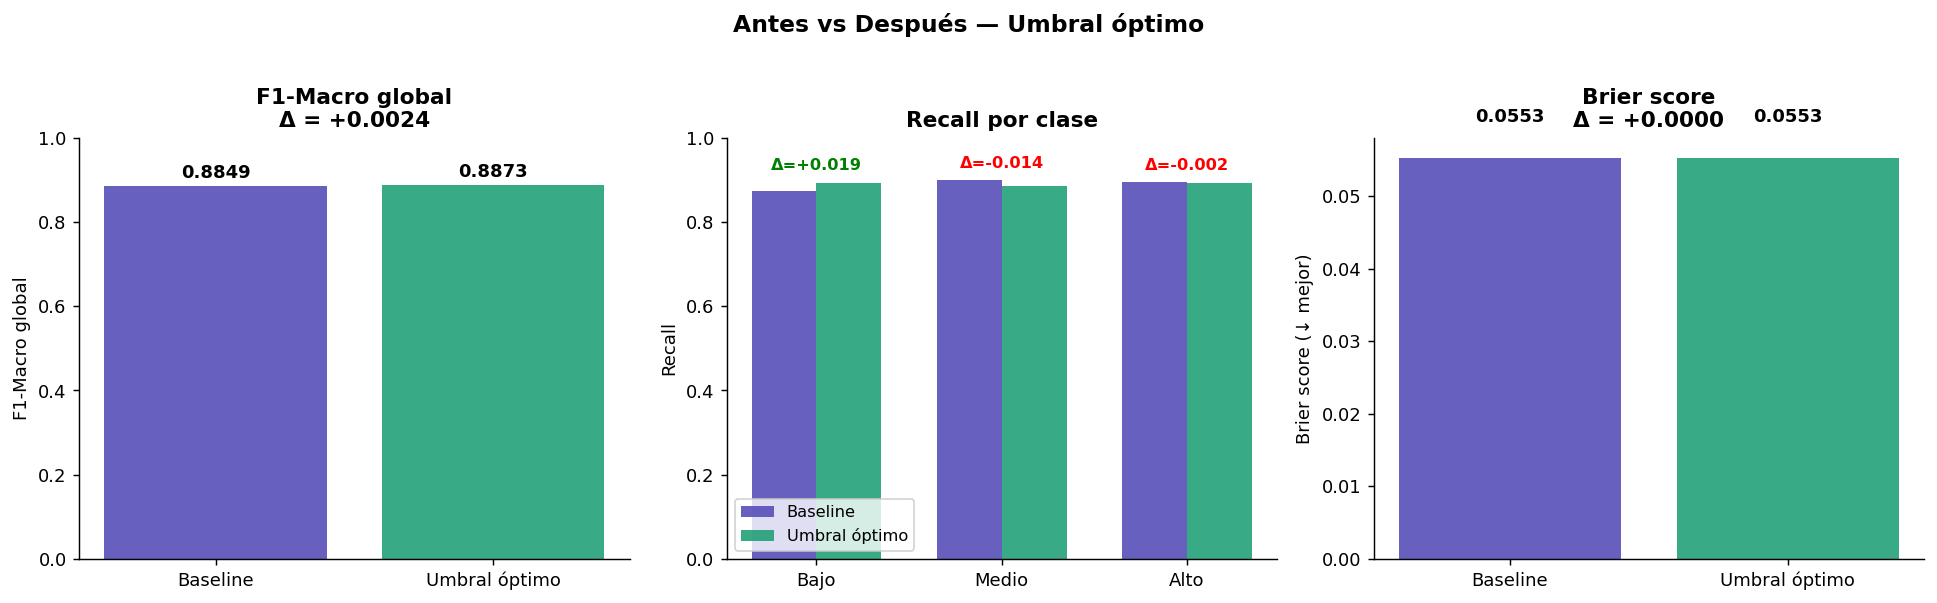

WindowsPath('reports/figures/19_mitigation_thresholds_before_after.png')

In [16]:
log.info("Calculando umbrales óptimos por clase con prioridad en Alto riesgo...")

thresholds = find_optimal_thresholds(
    y_true=y, y_proba=y_proba_oof,
    metric="f1",
    class_priority={0: 1.0, 1: 1.0, 2: 1.5},  # priorizar clase alta
)

print(f"\nUmbrales óptimos encontrados:")
for cls, thr in thresholds.items():
    print(f"  Clase {cls} ({RISK_NAMES.get(cls)}): {thr:.4f}")

# Aplicar umbrales
y_pred_thr = apply_thresholds(y_proba_oof, thresholds)

# Comparación baseline vs umbral
comp_thr = compare_before_after(
    y_true=y,
    y_pred_before=y_pred_oof, y_pred_after=y_pred_thr,
    y_proba_before=y_proba_oof, y_proba_after=y_proba_oof,  # proba no cambia
)

# Validar H1
h1_result = validate_hypothesis(
    comp_thr, hypothesis="H1", target_class=2,
    min_recall_gain=0.05, max_f1_loss=0.01,
)

print(f"\n{'='*70}")
print(f"RESULTADO H1 — Ajuste de umbral por clase")
print(f"{'='*70}")
print(f"  F1-Macro global:     {comp_thr['f1_macro_before']:.4f} → "
      f"{comp_thr['f1_macro_after']:.4f}  (Δ = {comp_thr['f1_macro_delta']:+.4f})")
print(f"  Recall clase Alto:   {comp_thr['recall_by_class'][2]['before']:.4f} → "
      f"{comp_thr['recall_by_class'][2]['after']:.4f}  "
      f"(Δ = {comp_thr['recall_by_class'][2]['delta']:+.4f})")
print(f"\n  H1 confirmada:       {'✓ SÍ' if h1_result['confirmed'] else '✗ NO'}")
print(f"    Recall gain ≥ {h1_result['threshold_recall']:.2f}: {h1_result['recall_pass']}")
print(f"    F1 loss ≤ {-h1_result['threshold_f1']:.2f}: {h1_result['f1_pass']}")

# Gráfico
plot_before_after(
    comp_thr,
    output_path=FIGURES_DIR / "19_mitigation_thresholds_before_after.png",
    mitigation_name="Umbral óptimo",
)

## 8. Mitigación 2: Calibración isotónica (H2)

**Hipótesis H2:** La calibración isotónica reduce el Brier score global
en al menos 0.02 sin degradar el F1-Macro.

La calibración se ajusta sobre las probabilidades OOF: se aprende una
función monótona por clase que mapea proba sin calibrar → proba real.

2026-07-03 16:14:19.193 | INFO     | __main__:<module>:1 - Ajustando calibradores isotónicos por clase...



RESULTADO H2 — Calibración isotónica
  F1-Macro global:  0.8849 → 0.8876  (Δ = +0.0026)
  Brier score:      0.0553 → 0.0540  (Δ = -0.0012)

  H2 confirmada:    ✗ NO
    Brier reducción ≥ 0.02: False
    F1 loss ≤ 0.01: True


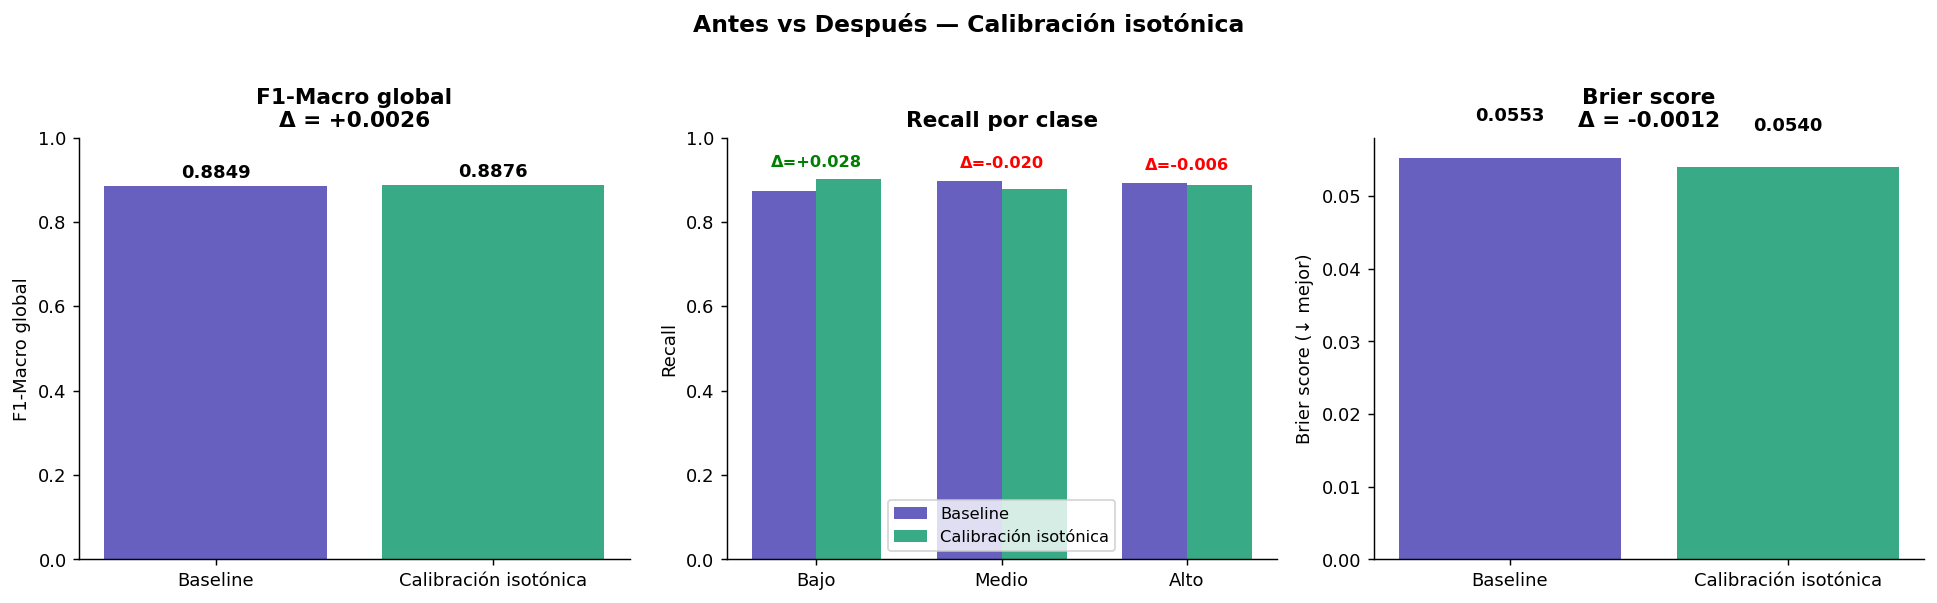

WindowsPath('reports/figures/20_mitigation_calibration_before_after.png')

In [17]:
log.info("Ajustando calibradores isotónicos por clase...")

calibrators = fit_isotonic_calibrators(
    y_true=y, y_proba=y_proba_oof, n_classes=3,
)

y_proba_cal = apply_isotonic_calibration(y_proba_oof, calibrators)
y_pred_cal  = np.argmax(y_proba_cal, axis=1)

comp_cal = compare_before_after(
    y_true=y,
    y_pred_before=y_pred_oof, y_pred_after=y_pred_cal,
    y_proba_before=y_proba_oof, y_proba_after=y_proba_cal,
)

h2_result = validate_hypothesis(
    comp_cal, hypothesis="H2",
    max_brier_gain=-0.02, max_f1_loss=0.01,
)

print(f"\n{'='*70}")
print(f"RESULTADO H2 — Calibración isotónica")
print(f"{'='*70}")
print(f"  F1-Macro global:  {comp_cal['f1_macro_before']:.4f} → "
      f"{comp_cal['f1_macro_after']:.4f}  (Δ = {comp_cal['f1_macro_delta']:+.4f})")
print(f"  Brier score:      {comp_cal['brier_before']:.4f} → "
      f"{comp_cal['brier_after']:.4f}  (Δ = {comp_cal['brier_delta']:+.4f})")
print(f"\n  H2 confirmada:    {'✓ SÍ' if h2_result['confirmed'] else '✗ NO'}")
print(f"    Brier reducción ≥ {-h2_result['threshold_brier']:.2f}: {h2_result['brier_pass']}")
print(f"    F1 loss ≤ {-h2_result['threshold_f1']:.2f}: {h2_result['f1_pass']}")

# Gráfico
plot_before_after(
    comp_cal,
    output_path=FIGURES_DIR / "20_mitigation_calibration_before_after.png",
    mitigation_name="Calibración isotónica",
)

## 9. Tabla consolidada final y persistencia

In [18]:
# Consolidar todos los slices en una sola tabla
all_slices = pd.concat([df_subject, df_class, df_activity, df_transition],
                       ignore_index=True) if activity_ids is not None else \
             pd.concat([df_subject, df_class], ignore_index=True)

# Guardar
slices_csv_path = REPORTS_DIR / "sprint5_slice_analysis.csv"
all_slices.to_csv(slices_csv_path, index=False)

# Guardar el resumen ejecutivo en JSON
summary_json = {
    "global_f1_oof":        global_f1,
    "total_slices_analyzed": len(all_slices),
    "problematic_slices":    [
        {
            "dimension":  p["dimension"],
            "slice_name": p["slice_name"],
            "n":          p["n"],
            "f1_macro":   p["f1_macro"],
            "gap":        p["gap"],
            "class_dist": p["class_dist"],
        }
        for p in top_problematic
    ],
    "mitigation_1_thresholds": {
        "thresholds":  thresholds,
        "f1_before":   comp_thr["f1_macro_before"],
        "f1_after":    comp_thr["f1_macro_after"],
        "f1_delta":    comp_thr["f1_macro_delta"],
        "recall_alto_before": comp_thr["recall_by_class"][2]["before"],
        "recall_alto_after":  comp_thr["recall_by_class"][2]["after"],
        "recall_alto_delta":  comp_thr["recall_by_class"][2]["delta"],
        "h1_confirmed":       h1_result["confirmed"],
    },
    "mitigation_2_calibration": {
        "f1_before":    comp_cal["f1_macro_before"],
        "f1_after":     comp_cal["f1_macro_after"],
        "f1_delta":     comp_cal["f1_macro_delta"],
        "brier_before": comp_cal["brier_before"],
        "brier_after":  comp_cal["brier_after"],
        "brier_delta":  comp_cal["brier_delta"],
        "h2_confirmed": h2_result["confirmed"],
    },
}

with open(REPORTS_DIR / "sprint5_summary.json", "w") as f:
    json.dump(summary_json, f, indent=2)

print(f"\nArtefactos generados:")
print(f"  • {slices_csv_path}")
print(f"  • {REPORTS_DIR / 'sprint5_summary.json'}")
print(f"  • {REPORTS_DIR / 'oof_predictions.npz'}")


Artefactos generados:
  • reports\sprint5_slice_analysis.csv
  • reports\sprint5_summary.json
  • reports\oof_predictions.npz


## 10. Resumen ejecutivo

In [19]:
print("\n" + "="*72)
print("RESUMEN EJECUTIVO — SPRINT 5: ANÁLISIS DE ERRORES Y SLICING")
print("="*72)

print(f"\n─── SLICES ANALIZADOS ──────────────────────────────────────────────")
print(f"  Total: {len(all_slices)} slices en 4 dimensiones")
print(f"  F1-Macro global (LOSO OOF): {global_f1:.4f}")

print(f"\n─── SLICES PROBLEMÁTICOS DETECTADOS ────────────────────────────────")
for i, p in enumerate(top_problematic, 1):
    print(f"  {i}. [{p['dimension']}] {p['slice_name']}:  "
          f"F1={p['f1_macro']:.4f}  n={p['n']}  gap={p['gap']:+.4f}")

print(f"\n─── MITIGACIÓN 1 — UMBRAL POR CLASE ────────────────────────────────")
print(f"  H1 confirmada:              {'✓ SÍ' if h1_result['confirmed'] else '✗ NO'}")
print(f"  Δ Recall clase Alto:        {comp_thr['recall_by_class'][2]['delta']:+.4f}")
print(f"  Δ F1-Macro global:          {comp_thr['f1_macro_delta']:+.4f}")

print(f"\n─── MITIGACIÓN 2 — CALIBRACIÓN ISOTÓNICA ───────────────────────────")
print(f"  H2 confirmada:              {'✓ SÍ' if h2_result['confirmed'] else '✗ NO'}")
print(f"  Δ Brier score:              {comp_cal['brier_delta']:+.4f}")
print(f"  Δ F1-Macro global:          {comp_cal['f1_macro_delta']:+.4f}")

print("="*72)


RESUMEN EJECUTIVO — SPRINT 5: ANÁLISIS DE ERRORES Y SLICING

─── SLICES ANALIZADOS ──────────────────────────────────────────────
  Total: 26 slices en 4 dimensiones
  F1-Macro global (LOSO OOF): 0.8849

─── SLICES PROBLEMÁTICOS DETECTADOS ────────────────────────────────
  1. [sujeto] 9:  F1=0.2505  n=638  gap=+0.6344
  2. [actividad PAMAP2] saltar:  F1=0.2874  n=4926  gap=+0.5976
  3. [actividad PAMAP2] caminar:  F1=0.2927  n=23861  gap=+0.5922
  4. [actividad PAMAP2] escaleras_abajo:  F1=0.3030  n=10485  gap=+0.5819
  5. [actividad PAMAP2] de_pie:  F1=0.3059  n=18985  gap=+0.5790

─── MITIGACIÓN 1 — UMBRAL POR CLASE ────────────────────────────────
  H1 confirmada:              ✗ NO
  Δ Recall clase Alto:        -0.0021
  Δ F1-Macro global:          +0.0024

─── MITIGACIÓN 2 — CALIBRACIÓN ISOTÓNICA ───────────────────────────
  H2 confirmada:              ✗ NO
  Δ Brier score:              -0.0012
  Δ F1-Macro global:          +0.0026
